In [5]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
#these are important functions that are in skchit that are used to evaluate classification ml models (supervised learning)
#accuracy_score: Computes the fraction of correctly classified samples.


df = pd.read_csv("data/features.csv") 
# using pandas to read the feature dataset/csv file that we made when reducing the data
# df = data frame in pandas that is two dimensional and is in tabular structure w rows and columns
df = df.sort_values(['Season', 'Round']).reset_index(drop=True) #used to reset the index of a data frame when iterating through it
# sorting values using season and round, so the season and grand prix
print(df.shape) # prints tuple of the df
df.head() # method used to print the first n rows of a data frame

(3458, 15)


,Season,Round,DriverId,Driver,Country,GridPosition,QualiGapToPole,DriverFormLast5,TeamFormLast5,TrackHistory,PointsFinishesLast5,HomeRace,CumulativeDriverPoints,CumulativeTeamPoints,Podium
0,2018,1,alonso,ALO,Australia,10.0,2.528,10.0,10.0,10.4,10.0,0,0.0,0.0,0
1,2018,1,bottas,BOT,Australia,15.0,0.925,10.0,10.0,8.2,10.0,0,0.0,0.0,0
2,2018,1,brendon_hartley,HAR,Australia,16.0,3.368,10.0,10.0,10.0,10.0,0,0.0,0.0,0
3,2018,1,ericsson,ERI,Australia,17.0,3.392,10.0,10.0,10.0,10.0,0,0.0,0.0,0
4,2018,1,gasly,GAS,Australia,20.0,4.131,10.0,15.0,11.4,10.0,0,0.0,0.0,0


In [8]:
# doing binary classification by labeling one dataframe as x and the other as y

feature_cols = [
    "GridPosition",
    "QualiGapToPole",
    "DriverFormLast5",
    "TeamFormLast5",
    "TrackHistory",
    "PointsFinishesLast5",
    "HomeRace",
    "CumulativeDriverPoints",
    "CumulativeTeamPoints",
]
label_col = "Podium"

X = df[feature_cols]
y = df[label_col]

train_mask = df["Season"] <= 2024 #training the model with seasons 2018-2023
test_mask  = df["Season"] == 2025 #testing if the model works with what it is trained with from 2023-2025

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print("Train rows:", X_train.shape[0], "| seasons:", sorted(df.loc[train_mask, "Season"].unique()))
print("Test rows: ", X_test.shape[0],  "| seasons:", sorted(df.loc[test_mask,  "Season"].unique()))


Train rows: 2979 | seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Test rows:  479 | seasons: [np.int64(2025)]


In [9]:
# the output that the print statement gave just tells us what is being tested and trained

import numpy as np
# need to build a base line model that doesnt nessarily use ml but uses a rule

# Rule: predict podium = 1 if grid position is 1, 2, or 3
baseline_preds = (X_test["GridPosition"] <= 3).astype(int) 
# this is saying that if the grid position was 1,2, or 3 then u can predict that they are on the podium

baseline_acc = accuracy_score(y_test, baseline_preds)
print(f"Baseline accuracy: {baseline_acc:.3f}")

Baseline accuracy: 0.925


In [10]:
# getting a value error for the logistic regression model saying that there are values w NaN
print(df.isnull().sum())
#running this to check for them

Season                    0
Round                     0
DriverId                  0
Driver                    0
Country                   0
GridPosition              0
QualiGapToPole            0
DriverFormLast5           0
TeamFormLast5             0
TrackHistory              0
PointsFinishesLast5       0
HomeRace                  0
CumulativeDriverPoints    0
CumulativeTeamPoints      0
Podium                    0
dtype: int64


In [11]:
# clearly there seemed to be 3 NaN rows for Grid Position so I fixed that in the code in phase 2

In [12]:
# this baseline accuracy isn't the only metric we need tho 

from sklearn.linear_model import LogisticRegression
# logistic regression is a classification model 
# logistic regression  predicts whether something belongs to one category or another

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]

print(f"Logistic Regression accuracy:  {accuracy_score(y_test, lr_preds):.3f}")
print(f"Logistic Regression precision: {precision_score(y_test, lr_preds):.3f}")
print(f"Logistic Regression recall:    {recall_score(y_test, lr_preds):.3f}")
print(f"Logistic Regression AUC:       {roc_auc_score(y_test, lr_probs):.3f}")

# Look at what the model actually learned
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Weight": lr.coef_[0]
}).sort_values("Weight")
print("\nLearned weights:")
print(coef_df)

Logistic Regression accuracy:  0.916
Logistic Regression precision: 0.758
Logistic Regression recall:    0.653
Logistic Regression AUC:       0.942

Learned weights:
                  Feature    Weight
6                HomeRace -0.498139
0            GridPosition -0.298140
3           TeamFormLast5 -0.159206
4            TrackHistory -0.097268
2         DriverFormLast5 -0.096746
5     PointsFinishesLast5 -0.026349
8    CumulativeTeamPoints -0.002109
7  CumulativeDriverPoints  0.006261
1          QualiGapToPole  0.057811


Decision Tree accuracy:  0.912
Decision Tree precision: 0.674
Decision Tree recall:    0.806
Decision Tree AUC:       0.943


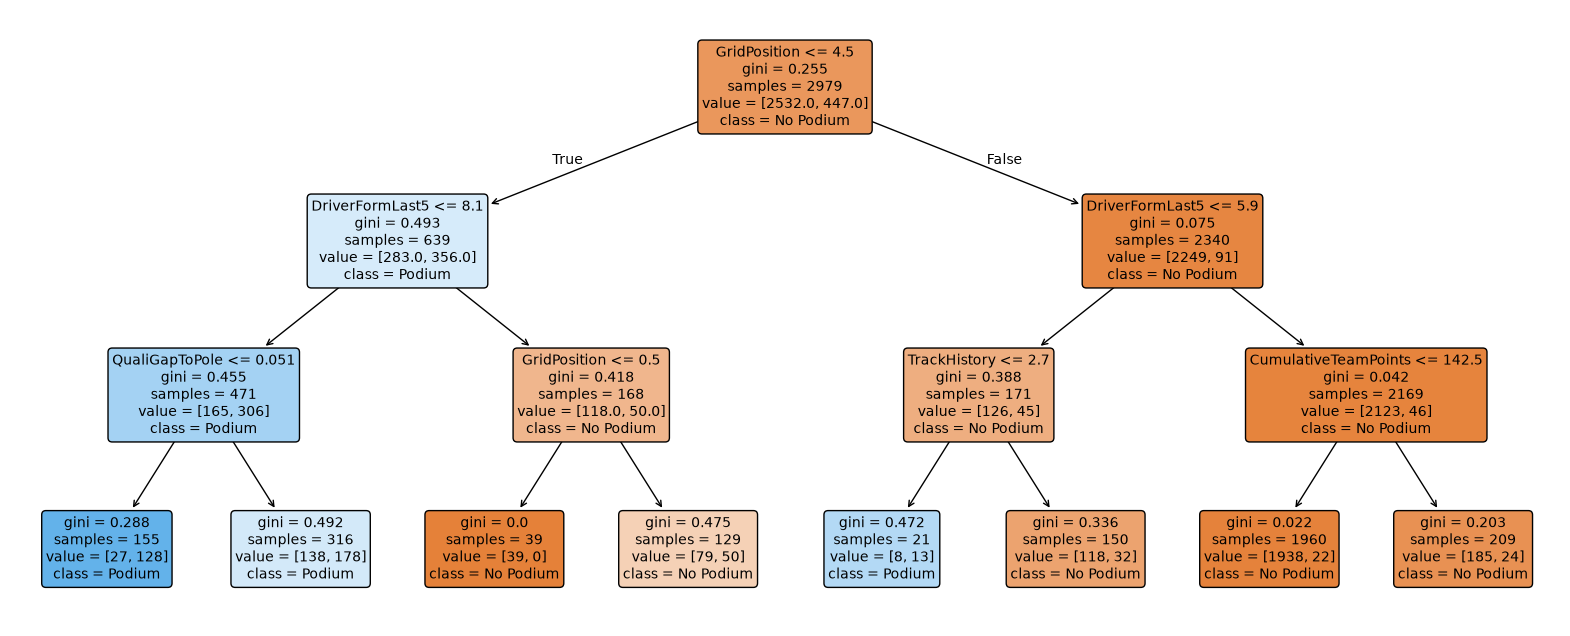

In [13]:
# now lets make the decision tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# decision trees make models by asking yes/no questions in a specific sequence
# it branches out answers left and right until it reaches a final answer
# 


tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
# DecisionTreeClassifier is sklearn's decision tree implementation
# max_depth=3 limits the tree to asking only 3 levels of yes/no questions

tree_preds = tree.predict(X_test)
tree_probs = tree.predict_proba(X_test)[:, 1]

print(f"Decision Tree accuracy:  {accuracy_score(y_test, tree_preds):.3f}")
print(f"Decision Tree precision: {precision_score(y_test, tree_preds):.3f}")
print(f"Decision Tree recall:    {recall_score(y_test, tree_preds):.3f}")
print(f"Decision Tree AUC:       {roc_auc_score(y_test, tree_probs):.3f}")

plt.figure(figsize=(20, 8))
plot_tree(tree, feature_names=feature_cols, class_names=["No Podium", "Podium"],
          filled=True, rounded=True, fontsize=10)
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
# this code above draws the tree out 


In [15]:
# Unlimited depth tree - watch it overfit
tree_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
tree_overfit.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_overfit.predict(X_train))
test_acc  = accuracy_score(y_test,  tree_overfit.predict(X_test))

print(f"Unlimited tree - Train accuracy: {train_acc:.3f}")
print(f"Unlimited tree - Test accuracy:  {test_acc:.3f}")

# what we did was remove the train limit, and the tree is able to ask infinite questions and that allows it to seperate every single row
# so in this tree, the model essentially memorizes word for word so if its asked smtg even slightly different it will predict smtg wrong
# the limit that we set for the decision tree above (3) is good because rather than memorizing individual cases it predicts off of general patterns


Unlimited tree - Train accuracy: 1.000
Unlimited tree - Test accuracy:  0.866


In [16]:
# Random forest is the direct answer to overfitting
# Instead of building one deep tree that memorizes training data, it builds hundreds of trees simultaneously
# random forest builds 200 trees all at once independently, then averages their votes

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print(f"Random Forest accuracy:  {accuracy_score(y_test, rf_preds):.3f}")
print(f"Random Forest precision: {precision_score(y_test, rf_preds):.3f}")
print(f"Random Forest recall:    {recall_score(y_test, rf_preds):.3f}")
print(f"Random Forest AUC:       {roc_auc_score(y_test, rf_probs):.3f}")

# Check for overfitting
train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc  = accuracy_score(y_test,  rf_preds)
print(f"\nTrain accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Gap: {train_acc - test_acc:.3f}")

Random Forest accuracy:  0.916
Random Forest precision: 0.716
Random Forest recall:    0.736
Random Forest AUC:       0.951

Train accuracy: 0.932
Test accuracy:  0.916
Gap: 0.015


In [17]:
# now we are going to implement and use xgboost bc the random forest is our current best model

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]

print(f"XGBoost accuracy:  {accuracy_score(y_test, xgb_preds):.3f}")
print(f"XGBoost precision: {precision_score(y_test, xgb_preds):.3f}")
print(f"XGBoost recall:    {recall_score(y_test, xgb_preds):.3f}")
print(f"XGBoost AUC:       {roc_auc_score(y_test, xgb_probs):.3f}")

train_acc = accuracy_score(y_train, xgb.predict(X_train))
test_acc  = accuracy_score(y_test, xgb_preds)
print(f"\nTrain accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Gap: {train_acc - test_acc:.3f}")

# Feature importance
import pandas as pd
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)
print("\nFeature importances:")
print(importance_df)

XGBoost accuracy:  0.914
XGBoost precision: 0.712
XGBoost recall:    0.722
XGBoost AUC:       0.944

Train accuracy: 0.955
Test accuracy:  0.914
Gap: 0.041

Feature importances:
                  Feature  Importance
0            GridPosition    0.657248
2         DriverFormLast5    0.070321
1          QualiGapToPole    0.050194
8    CumulativeTeamPoints    0.048137
4            TrackHistory    0.044882
3           TeamFormLast5    0.040191
7  CumulativeDriverPoints    0.035877
5     PointsFinishesLast5    0.027753
6                HomeRace    0.025396


In [19]:
# random forest still appears to the best model
# now we have to test if the prediction model works

import joblib # the most common way to save scklearn models
import os

os.makedirs("model", exist_ok=True)

# save the random forest (my best model)
joblib.dump(rf, "model/random_forest.pkl")

# save the feature column list so you never forget what order features go in
joblib.dump(feature_cols, "model/feature_cols.pkl")

print("Model saved to model/random_forest.pkl")
print("Feature columns saved to model/feature_cols.pkl")
print("Features expected:", feature_cols)

Model saved to model/random_forest.pkl
Feature columns saved to model/feature_cols.pkl
Features expected: ['GridPosition', 'QualiGapToPole', 'DriverFormLast5', 'TeamFormLast5', 'TrackHistory', 'PointsFinishesLast5', 'HomeRace', 'CumulativeDriverPoints', 'CumulativeTeamPoints']
